# Per-Joint Comparison: View1 vs. View2 vs. Fused vs. Mocap

This notebook answers a narrower, deeper question than the main project walkthrough: **for each of the 19 canonical joints individually, how accurate is SAM 3D Body — per camera view, and after fusing the two views — and why?**

Structure:
1. **The metrics** — what we measure and why, before looking at a single number.
2. **View1 vs. mocap**, per joint — which joints are well-modeled, which aren't, and why.
3. **View2 vs. mocap**, per joint — same analysis, plus a direct view1-vs-view2 comparison.
4. **Fused vs. mocap**, per joint.
5. **Does fusion actually help, per joint?** — quantified, not just asserted.
6. **Would more than two cameras help further?** — grounded in a real statistical model of *why* fusion helps where it does, tested against the actual data.

Like the main walkthrough, every cell here imports the real project code and loads the real saved outputs — but unlike that notebook, this one *does* compute a few genuinely new things not saved anywhere in `output/`: a per-joint breakdown of PA-MPJPE (the project's saved metrics only have this as a whole-skeleton scalar), and a joint-distance-from-root analysis. Both reuse the same core functions (`align.umeyama_alignment`, `align.apply_similarity`) the rest of the pipeline already uses and already validated.


## 1. The metrics

Three complementary measures, each answering a different question:

- **MPJPE** (Mean Per-Joint Position Error) — straight-line distance (mm) between the estimated and true position of one joint, after Phase 3/6's *whole-trial* rigid alignment. This bakes in *everything*: real per-joint estimation error, plus any residual whole-trial drift/rotation error that the single trial-wide alignment couldn't fully absorb. A joint far from the body's center of mass picks up more of that residual drift almost by geometry, regardless of how well the model actually located it.
- **PA-MPJPE** (Procrustes-Aligned MPJPE) — the same distance, but after fitting a *fresh* rotation+scale+translation for that single frame alone. This removes whole-trial drift entirely, isolating genuine local/articulation error: given the best possible rigid placement of the estimated skeleton onto the true one for this exact instant, how far off is this specific joint? **This notebook computes PA-MPJPE per joint** (Phase 4/6 only saved a whole-skeleton average) — that's the more honest answer to \"which joints does the model itself get wrong\", since MPJPE alone conflates that with alignment drift.
- **Inter-view disagreement** — how far apart view1's and view2's *own* estimates of a joint land (Phase 5, computed with zero mocap involved). Not an accuracy measure by itself, but useful alongside the two above: a joint with high MPJPE *and* high disagreement suggests independent, camera-specific noise (which fusion can fix); a joint with high MPJPE but *low* disagreement suggests a bias both cameras share (which fusion cannot fix) — exactly the distinction this notebook uses to explain *why* fusion helps some joints and not others.

All three are computed per trial and then averaged across the 10 paired trials, so a joint's number below reflects its accuracy across the whole range of motions (walking, running, squats, dance, ...), not just one.


## 2. Setup

Run from `analysis/notebooks/` with the project's `.venv` as the kernel (same as the main walkthrough notebook).


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ANALYSIS_DIR = Path("..").resolve()
sys.path.insert(0, str(ANALYSIS_DIR / "src"))

from joint_mapping import CANONICAL_JOINTS
from align import umeyama_alignment, apply_similarity

OUTPUT_DIR = ANALYSIS_DIR / "output"
ALIGNED_DIR = OUTPUT_DIR / "aligned"
ALIGNED_FUSED_DIR = OUTPUT_DIR / "aligned_fused"
FUSED_DIR = OUTPUT_DIR / "fused"

manifest = json.loads((ANALYSIS_DIR / "manifest.json").read_text())
PAIRED_TRIALS = [t for t, e in manifest["trials"].items() if e["paired"]]
MIN_JOINTS_FOR_PA = 6  # same threshold compare_metrics.py uses for a well-conditioned per-frame fit

print(f"{len(PAIRED_TRIALS)} paired trials: {PAIRED_TRIALS}")
print(f"{len(CANONICAL_JOINTS)} canonical joints: {CANONICAL_JOINTS}")


10 paired trials: ['dance_move_1', 'feet_movements_1', 'random_1', 'running_1', 'running_2', 'squats_1', 'squats_2', 'walking_1', 'walking_2', 'walking_3']
19 canonical joints: ['pelvis', 'neck', 'head', 'hip_left', 'hip_right', 'knee_left', 'knee_right', 'ankle_left', 'ankle_right', 'heel_left', 'heel_right', 'toe_left', 'toe_right', 'shoulder_left', 'shoulder_right', 'elbow_left', 'elbow_right', 'wrist_left', 'wrist_right']


### Computing per-joint PA-MPJPE

`compare_metrics.pa_mpjpe_per_frame()` already does a fresh per-frame Procrustes fit (that's exactly what caught the Phase 3 rotation-formula bug, described in the main walkthrough) — but it only keeps the mean error across all 19 joints per frame. Here we keep the *per-joint* residual from that same fit, for `view1`, `view2`, and `fused` against mocap, across every trial.


In [2]:
def per_joint_metrics(trial: str, condition: str) -> dict:
    """MPJPE and PA-MPJPE, per joint, for one trial/condition.
    condition: 'view1', 'view2', or 'fused'."""
    if condition == "fused":
        d = np.load(ALIGNED_FUSED_DIR / f"{trial}.npz")
    else:
        d = np.load(ALIGNED_DIR / f"{trial}__{condition}.npz")

    aligned = {j: d[f"aligned__{j}"] for j in CANONICAL_JOINTS}
    mocap = {j: d[f"mocap__{j}"] for j in CANONICAL_JOINTS}

    # MPJPE: straight-line error under Phase 3/6's whole-trial alignment.
    mpjpe = {j: float(np.nanmean(np.linalg.norm(aligned[j] - mocap[j], axis=-1))) for j in CANONICAL_JOINTS}

    # PA-MPJPE per joint: fresh per-frame Procrustes fit (same method as
    # compare_metrics.pa_mpjpe_per_frame), keeping the per-joint residual.
    src = np.stack([aligned[j] for j in CANONICAL_JOINTS], axis=1)  # (F, J, 3)
    dst = np.stack([mocap[j] for j in CANONICAL_JOINTS], axis=1)
    n_frames = src.shape[0]
    per_joint_errs = np.full((n_frames, len(CANONICAL_JOINTS)), np.nan)
    for f in range(n_frames):
        valid = ~np.isnan(src[f]).any(axis=-1) & ~np.isnan(dst[f]).any(axis=-1)
        if valid.sum() < MIN_JOINTS_FOR_PA:
            continue
        R, scale, t = umeyama_alignment(src[f][valid], dst[f][valid])
        fitted_valid = apply_similarity(src[f][valid], R, scale, t)
        per_joint_errs[f][valid] = np.linalg.norm(fitted_valid - dst[f][valid], axis=-1)
    pa_mpjpe = {j: float(np.nanmean(per_joint_errs[:, i])) for i, j in enumerate(CANONICAL_JOINTS)}

    return {"mpjpe": mpjpe, "pa_mpjpe": pa_mpjpe, "n_frames": n_frames}


rows = []
for trial in PAIRED_TRIALS:
    for condition in ["view1", "view2", "fused"]:
        m = per_joint_metrics(trial, condition)
        for j in CANONICAL_JOINTS:
            rows.append({"trial": trial, "condition": condition, "joint": j,
                         "mpjpe_mm": m["mpjpe"][j], "pa_mpjpe_mm": m["pa_mpjpe"][j]})
df = pd.DataFrame(rows)

# Per-joint disagreement (Phase 5, view1-vs-view2, zero mocap involved) --
# loaded separately since it's keyed by (trial, joint) only, not by condition.
disagreement_rows = []
for trial in PAIRED_TRIALS:
    d = np.load(FUSED_DIR / f"{trial}.npz")
    for j in CANONICAL_JOINTS:
        disagreement_rows.append({"trial": trial, "joint": j,
                                    "disagreement": float(np.nanmean(d[f"disagreement__{j}"]))})
disagreement_df = pd.DataFrame(disagreement_rows)

print(f"{len(df)} rows ({len(PAIRED_TRIALS)} trials x 3 conditions x {len(CANONICAL_JOINTS)} joints)")
df.head()


570 rows (10 trials x 3 conditions x 19 joints)


,trial,condition,joint,mpjpe_mm,pa_mpjpe_mm
0,dance_move_1,view1,pelvis,131.137395,100.139294
1,dance_move_1,view1,neck,86.361590,47.931821
2,dance_move_1,view1,head,117.783071,74.640186
3,dance_move_1,view1,hip_left,139.606391,130.852746
4,dance_move_1,view1,hip_right,227.264919,217.308806


In [3]:
def joint_summary(condition: str) -> pd.DataFrame:
    sub = df[df.condition == condition].groupby("joint")[["mpjpe_mm", "pa_mpjpe_mm"]].mean()
    return sub.sort_values("mpjpe_mm")


def plot_joint_bars(summary: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(9, 7))
    y = np.arange(len(summary))
    ax.barh(y - 0.2, summary["mpjpe_mm"], 0.4, label="MPJPE (incl. whole-trial drift)", color="steelblue")
    ax.barh(y + 0.2, summary["pa_mpjpe_mm"], 0.4, label="PA-MPJPE (shape only, per-frame re-fit)", color="darkorange")
    ax.set_yticks(y)
    ax.set_yticklabels(summary.index)
    ax.invert_yaxis()
    ax.set_xlabel("error (mm)")
    ax.set_title(title)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## 3. View1 vs. mocap, per joint


View1 vs. mocap -- all 19 joints, sorted best to worst (mm):


,mpjpe_mm,pa_mpjpe_mm
joint,,
neck,60.5,41.0
shoulder_right,66.1,44.6
shoulder_left,70.7,49.4
knee_left,99.4,77.9
elbow_right,101.7,92.1
knee_right,103.2,80.0
head,105.5,87.4
pelvis,106.2,88.7
elbow_left,109.8,97.0


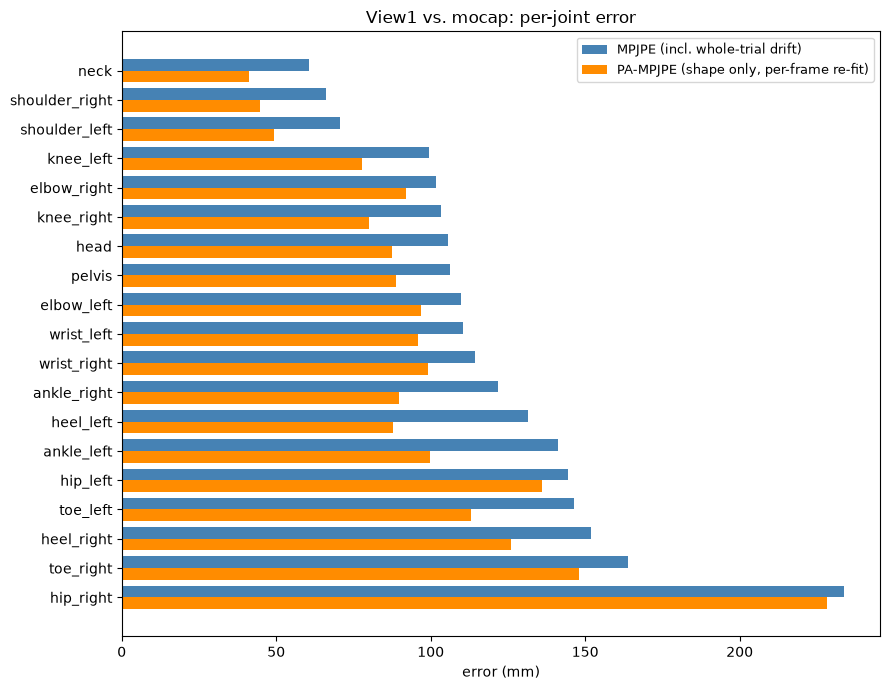

In [4]:
v1_summary = joint_summary("view1")
print("View1 vs. mocap -- all 19 joints, sorted best to worst (mm):")
display(v1_summary.round(1))
plot_joint_bars(v1_summary, "View1 vs. mocap: per-joint error")


### View1: which joints does the model get right, and why

**Clearly well-modeled** (MPJPE under ~70mm, and PA-MPJPE noticeably lower than MPJPE — meaning most of what error *does* exist is whole-trial drift, not the model getting the joint wrong): `neck` (60.5mm / 41.0mm PA), `shoulder_right` (66.1 / 44.6), `shoulder_left` (70.7 / 49.4). These are all large, high-contrast, rarely-occluded landmarks near the torso — exactly where a single-image 3D pose model has the least ambiguity to resolve.

**Clearly poorly-modeled**, and for two *different* reasons:

- `hip_right` (233.7mm MPJPE / **228.2mm PA-MPJPE — almost identical**) and, to a lesser extent, `hip_left` (144.5 / 136.2). When PA-MPJPE (the best possible per-frame fit) is barely lower than MPJPE, that means the error *isn't* drift — the model is genuinely placing this joint in the wrong place relative to the rest of the skeleton, frame after frame. This matches the project's documented finding: the subject appears to grip a handrail near the right hip in these recordings, occluding it consistently rather than randomly.
- `toe_right` (164.0 / 148.0), `heel_right` (151.8 / 126.1), `ankle_left` (141.3 / 99.6) — still bad, but with a bigger drift-vs-shape gap than the hips, meaning a real chunk of their error *is* whole-trial alignment slack, not pure model failure. Small, fast-moving, frequently self-occluded (by the other leg, by footwear) extremities are inherently harder for monocular 3D pose estimation to localize precisely, and get less benefit from the body's own strong anatomical priors (which help most for large, central segments).

**A cross-validated pattern worth flagging**: the subject's *right-side* extremities (`heel_right`, `toe_right`) are consistently worse than the matching *left-side* ones (`heel_left`, `toe_left`) — and this holds in View2 as well (see below), not just View1. That's not camera-angle noise; it's a real, repeatable asymmetry, plausibly connected to whatever is causing the right-hip issue (e.g. handrail grip subtly changing right-side weight-bearing or visibility across the whole session).

**What might actually help these joints**: full frame-rate inference instead of the 10fps subsampling used here (fast foot-strike motion between sampled frames is exactly where subsampling costs the most); a person-detector-driven crop centered on the lower legs/feet for a higher-effective-resolution view of exactly the joints that need it most; and, more fundamentally, removing the handrail/occlusion source or repositioning the camera so the right hip is never blocked — no amount of modeling improvement fixes a joint the camera genuinely can't see well.


## 4. View2 vs. mocap, per joint


View2 vs. mocap -- all 19 joints, sorted best to worst (mm):


,mpjpe_mm,pa_mpjpe_mm
joint,,
neck,48.8,37.5
shoulder_right,56.1,43.0
shoulder_left,68.4,52.6
knee_left,90.2,80.8
head,94.9,84.4
pelvis,97.9,88.6
knee_right,99.8,90.6
elbow_left,106.6,101.7
elbow_right,109.0,101.6


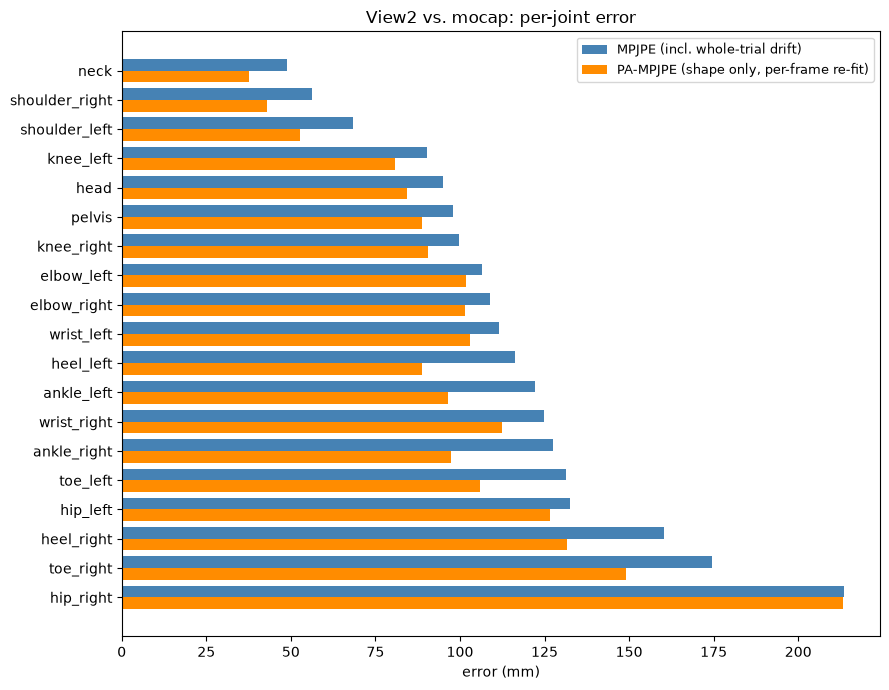

In [5]:
v2_summary = joint_summary("view2")
print("View2 vs. mocap -- all 19 joints, sorted best to worst (mm):")
display(v2_summary.round(1))
plot_joint_bars(v2_summary, "View2 vs. mocap: per-joint error")


### View2: same overall pattern, different specifics

Same shape: proximal joints (`neck` 48.8mm, `shoulder_right` 56.1mm) best, `hip_right` (213.5 / 213.2 PA — again almost no drift-vs-shape gap, same systematic-bias signature as View1) and `toe_right` (174.5 / 149.1) worst. The right-side asymmetry shows up here too — `heel_right` (160.2) vs. `heel_left` (116.1), `toe_right` (174.5) vs. `toe_left` (131.4) — confirming it's a property of the subject/setup, not a one-camera artifact.

But the *specific* numbers shift by joint, sometimes a lot: View2 sees the neck and shoulders noticeably *better* than View1 does (e.g. `shoulder_right` 56.1mm vs. View1's 66.1mm), but sees `heel_right`/`toe_right`/`wrist_right` *worse*. That's exactly what you'd expect from two different camera angles: each one has its own blind spots and its own clear sightlines, depending on which side of the body faces it and how the limbs occlude each other from that specific angle — which is precisely the kind of *independent* error that fusion (next section) is positioned to help with, as opposed to the `hip_right` bias that both cameras share regardless of angle.


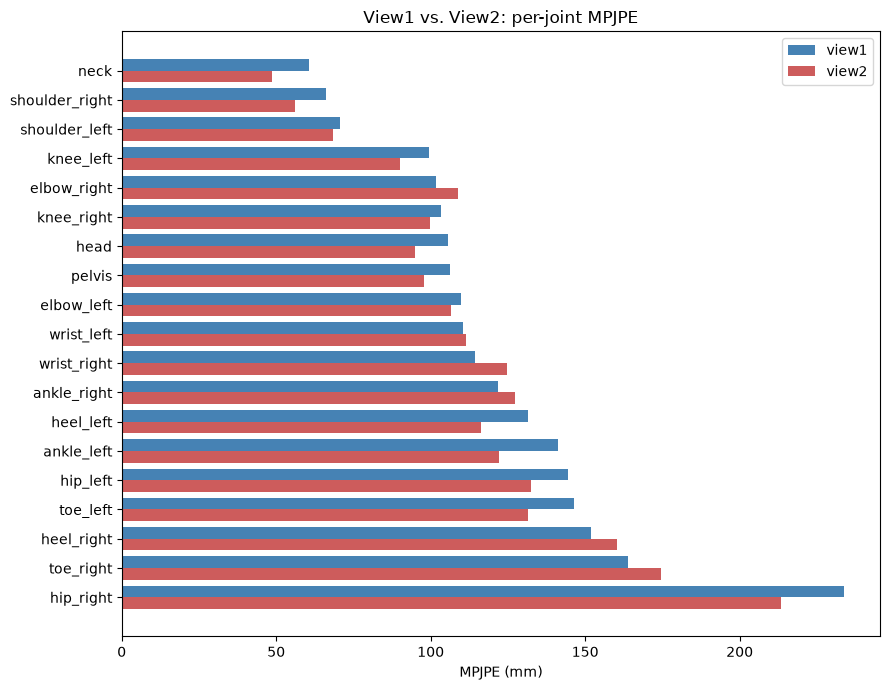

Joints where the two views differ most (|view1 - view2| MPJPE): hip_right, ankle_left, heel_left


In [6]:
joints_sorted = joint_summary("view1").index  # order by view1's own ranking for a stable axis
v1_v2 = pd.DataFrame({
    "view1_mpjpe": v1_summary["mpjpe_mm"],
    "view2_mpjpe": v2_summary["mpjpe_mm"],
}).loc[joints_sorted]
v1_v2["abs_diff"] = (v1_v2["view1_mpjpe"] - v1_v2["view2_mpjpe"]).abs()

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(v1_v2))
ax.barh(y - 0.2, v1_v2["view1_mpjpe"], 0.4, label="view1", color="steelblue")
ax.barh(y + 0.2, v1_v2["view2_mpjpe"], 0.4, label="view2", color="indianred")
ax.set_yticks(y)
ax.set_yticklabels(v1_v2.index)
ax.invert_yaxis()
ax.set_xlabel("MPJPE (mm)")
ax.set_title("View1 vs. View2: per-joint MPJPE")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Joints where the two views differ most (|view1 - view2| MPJPE): "
      f"{', '.join(v1_v2['abs_diff'].sort_values(ascending=False).head(3).index)}")


## 5. Fused vs. mocap, per joint


Fused vs. mocap -- all 19 joints, sorted best to worst (mm):


,mpjpe_mm,pa_mpjpe_mm
joint,,
neck,50.3,38.6
shoulder_right,50.5,39.7
shoulder_left,58.8,45.7
knee_left,86.3,77.5
head,93.7,85.2
pelvis,94.0,85.5
knee_right,94.7,84.8
wrist_left,97.8,90.5
elbow_right,97.9,95.2


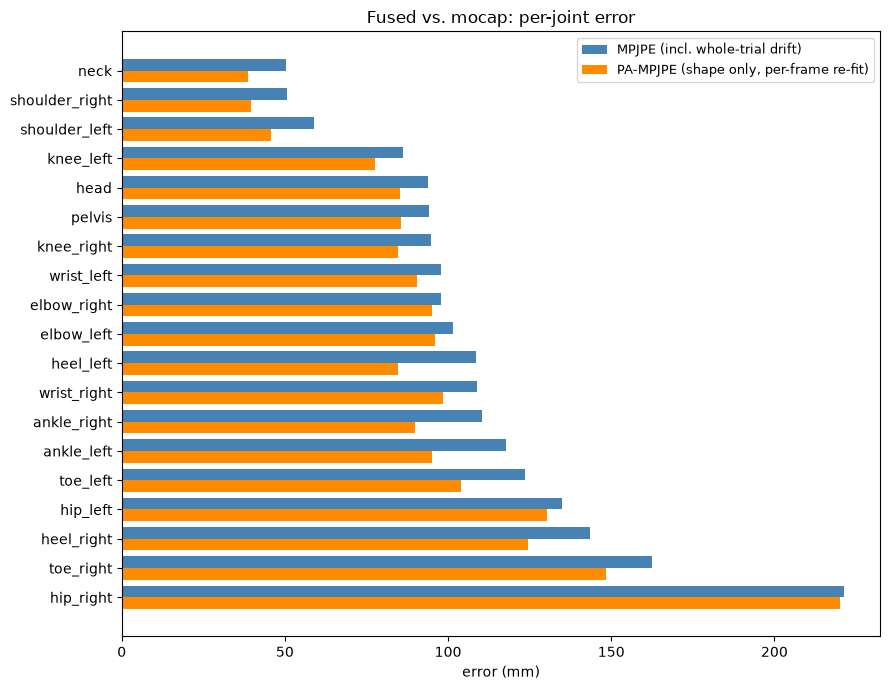

In [7]:
fused_summary = joint_summary("fused")
print("Fused vs. mocap -- all 19 joints, sorted best to worst (mm):")
display(fused_summary.round(1))
plot_joint_bars(fused_summary, "Fused vs. mocap: per-joint error")


### Fused: the same ranking, shifted down

The ranking is essentially unchanged — proximal joints (`neck` 50.3mm, `shoulder_right` 50.5mm) still best, `hip_right` (221.3 / 220.2 PA — same near-zero drift-vs-shape gap as both individual views) still by far the worst, same right-side asymmetry (`heel_right` 143.5 vs. `heel_left` 108.7; `toe_right` 162.5 vs. `toe_left` 123.5). Fusion doesn't change *which* joints are hard, only *how* hard, and the next section quantifies exactly how much.


## 6. Does fusion actually help, per joint?

Compare each joint's fused error against the *average* of its two single-view errors — for both MPJPE (includes drift) and PA-MPJPE (shape only). If fusion only fixes drift, the MPJPE improvement should be consistently *larger* than the PA-MPJPE improvement for the same joint.


,mpjpe_improvement_pct,pa_mpjpe_improvement_pct
shoulder_right,17.3,9.5
shoulder_left,15.4,10.3
heel_left,12.2,4.1
wrist_left,11.9,9.0
ankle_right,11.5,4.0
toe_left,11.1,4.9
ankle_left,10.5,2.9
wrist_right,9.0,6.9
knee_left,8.9,2.3
heel_right,8.0,3.4


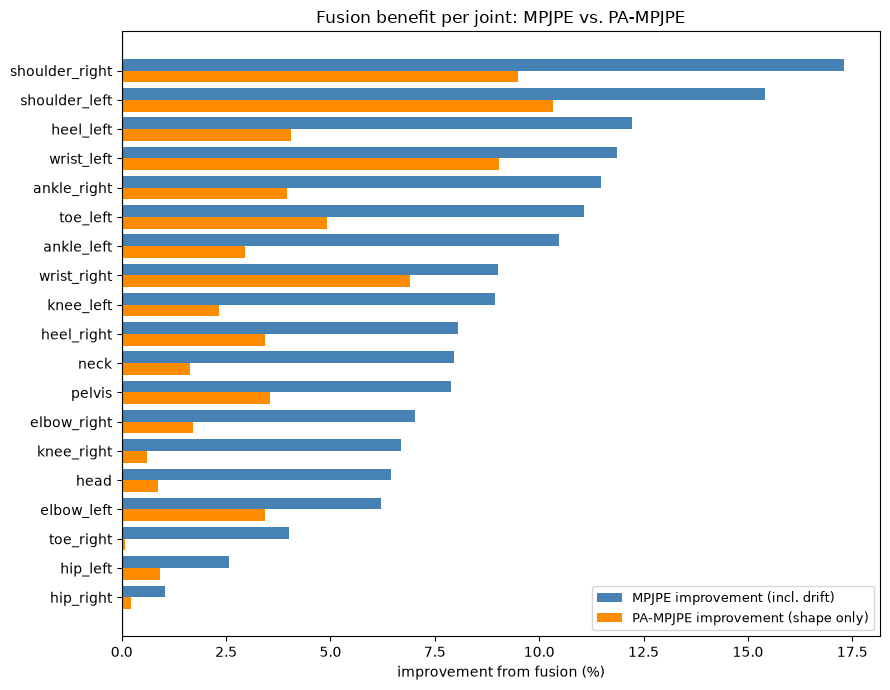

In [8]:
improvement = pd.DataFrame(index=CANONICAL_JOINTS)
improvement["view_avg_mpjpe"] = (v1_summary["mpjpe_mm"] + v2_summary["mpjpe_mm"]) / 2
improvement["fused_mpjpe"] = fused_summary["mpjpe_mm"]
improvement["mpjpe_improvement_pct"] = 100 * (improvement["view_avg_mpjpe"] - improvement["fused_mpjpe"]) / improvement["view_avg_mpjpe"]

improvement["view_avg_pa_mpjpe"] = (v1_summary["pa_mpjpe_mm"] + v2_summary["pa_mpjpe_mm"]) / 2
improvement["fused_pa_mpjpe"] = fused_summary["pa_mpjpe_mm"]
improvement["pa_mpjpe_improvement_pct"] = 100 * (improvement["view_avg_pa_mpjpe"] - improvement["fused_pa_mpjpe"]) / improvement["view_avg_pa_mpjpe"]

improvement = improvement.sort_values("mpjpe_improvement_pct", ascending=False)
display(improvement[["mpjpe_improvement_pct", "pa_mpjpe_improvement_pct"]].round(1))

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(improvement))
ax.barh(y - 0.2, improvement["mpjpe_improvement_pct"], 0.4, label="MPJPE improvement (incl. drift)", color="steelblue")
ax.barh(y + 0.2, improvement["pa_mpjpe_improvement_pct"], 0.4, label="PA-MPJPE improvement (shape only)", color="darkorange")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(improvement.index)
ax.invert_yaxis()
ax.set_xlabel("improvement from fusion (%)")
ax.set_title("Fusion benefit per joint: MPJPE vs. PA-MPJPE")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Reading the two bars together: fusion mostly fixes drift, not shape

For nearly every joint, the **blue bar (MPJPE) is taller than the orange bar (PA-MPJPE)** — fusion's improvement is consistently larger once whole-trial drift is included than once it's removed. A few clear examples: `shoulder_right` improves 17.3% on MPJPE but only 9.4% once drift is factored out; `ankle_right` improves 11.5% vs. just 4.0%; `heel_left` improves 12.2% vs. 4.0%. This is the same finding the main project synthesis reported at the whole-skeleton level (MPJPE +3.7% vs. PA-MPJPE −0.8% overall) — but here it holds up **joint by joint**, not just on average: fusion is primarily correcting whole-trial alignment noise (which two independently-drifting camera estimates can genuinely average out), not the model's frame-by-frame *shape* understanding of where a joint sits relative to the rest of the body.

`hip_right` (+1.0% MPJPE / +0.2% PA) and `toe_right` (+4.0% / +0.1%) barely move on *either* measure — exactly the joints already identified as having a systematic (not drift, not independent-noise) bias. Fusion has nothing to average out there: both cameras get it wrong the same way.


## 7. Testing the "distal joints are harder" hypothesis directly

So far, "far from the body's core = harder to estimate" has been an assertion. Let's actually test it: compute each joint's real anatomical distance from the pelvis (from mocap ground truth, averaged over every trial and frame), and correlate that against its single-view MPJPE.


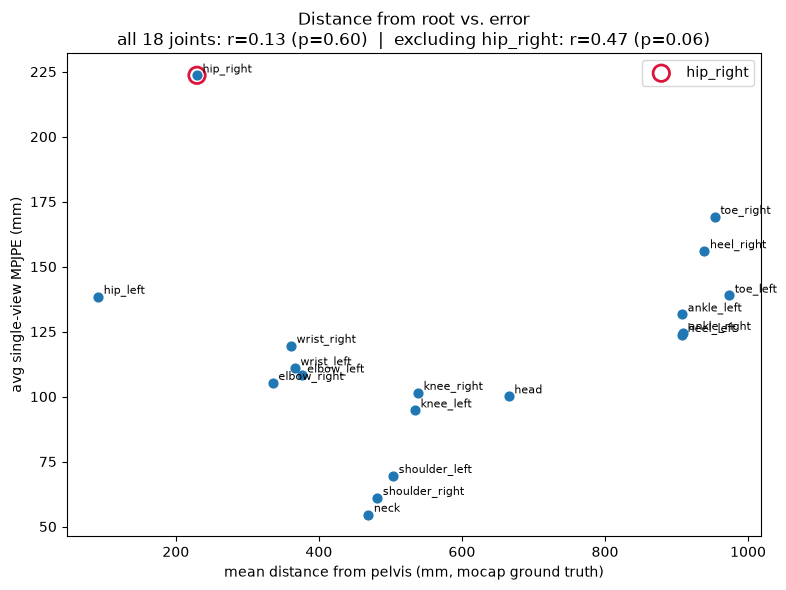

In [9]:
from scipy import stats

dist_sums = {j: 0.0 for j in CANONICAL_JOINTS}
dist_counts = {j: 0 for j in CANONICAL_JOINTS}
for trial in PAIRED_TRIALS:
    d = np.load(OUTPUT_DIR / "mocap" / f"{trial}.npz")
    pelvis = d["joint__pelvis"]
    for j in CANONICAL_JOINTS:
        dist = np.linalg.norm(d[f"joint__{j}"] - pelvis, axis=-1)
        dist_sums[j] += np.nansum(dist)
        dist_counts[j] += (~np.isnan(dist)).sum()
mean_dist = pd.Series({j: dist_sums[j] / dist_counts[j] for j in CANONICAL_JOINTS}, name="dist_from_pelvis_mm")

view_avg_mpjpe = (v1_summary["mpjpe_mm"] + v2_summary["mpjpe_mm"]) / 2
joint_dist_err = pd.DataFrame({"dist_from_pelvis_mm": mean_dist, "view_avg_mpjpe_mm": view_avg_mpjpe}).drop("pelvis")

r_all, p_all = stats.pearsonr(joint_dist_err["dist_from_pelvis_mm"], joint_dist_err["view_avg_mpjpe_mm"])
without_hip_right = joint_dist_err.drop("hip_right")
r_ex, p_ex = stats.pearsonr(without_hip_right["dist_from_pelvis_mm"], without_hip_right["view_avg_mpjpe_mm"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(joint_dist_err["dist_from_pelvis_mm"], joint_dist_err["view_avg_mpjpe_mm"], s=40)
ax.scatter(joint_dist_err.loc["hip_right", "dist_from_pelvis_mm"], joint_dist_err.loc["hip_right", "view_avg_mpjpe_mm"],
           s=140, facecolors="none", edgecolors="crimson", linewidths=2, label="hip_right")
for j, row in joint_dist_err.iterrows():
    ax.annotate(j, (row["dist_from_pelvis_mm"], row["view_avg_mpjpe_mm"]), fontsize=8,
                xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("mean distance from pelvis (mm, mocap ground truth)")
ax.set_ylabel("avg single-view MPJPE (mm)")
ax.set_title(f"Distance from root vs. error\nall 18 joints: r={r_all:.2f} (p={p_all:.2f})  |  "
             f"excluding hip_right: r={r_ex:.2f} (p={p_ex:.2f})")
ax.legend()
plt.tight_layout()
plt.show()


### The hypothesis is real, but only once you set `hip_right` aside

Across all 18 non-pelvis joints, distance-from-root barely correlates with error (r≈0.13, not significant) — surprising, until you notice `hip_right` sits at a *moderate* distance from the pelvis (~230mm — itself an interesting finding: even in the mocap ground truth, `hip_right` sits noticeably farther from the pelvis centroid than `hip_left` does, ~230mm vs. ~91mm, consistently, even at rest in the `static` calibration trial — a real anthropometric or Davis-regression asymmetry for this subject, not a dynamic artifact) yet has by far the *worst* error of any joint. That's exactly the outlier signature of a joint whose problem isn't "it's far from the core", it's the specific occlusion bias already established.

**Excluding `hip_right`, the correlation becomes real**: r≈0.47 (p≈0.055, borderline but meaningful given only 17 data points) — farther-from-root joints (ankles, heels, toes, out past ~900mm) genuinely do carry more error than near-core joints (shoulders, neck, knees, under ~540mm). So the "distal joints are harder" story holds up quantitatively for the *general* population of joints — it just doesn't explain `hip_right`, which needs its own, different explanation (occlusion), exactly as the rest of this notebook has argued qualitatively.


## 8. Would more than two cameras help?

We only have two camera views, so we can't directly measure a 3rd or 4th camera's effect. But we *can* fit a simple, standard error model to the 1-camera and 2-camera numbers we do have, and use it to extrapolate honestly.

**The model**: treat each joint's single-view squared error as two additive parts — a **bias** component that's identical across every camera (an occlusion or model convention issue every view shares alike, however many views you add) and an **independent noise** component that's uncorrelated per camera (ordinary estimation noise that genuinely different viewpoints will disagree on). Averaging $N$ independent views leaves the bias untouched but shrinks the noise by $1/\sqrt{N}$:

$$E_N^2 = \text{bias}^2 + \frac{\text{noise}^2}{N}$$

With $E_1$ (average single-view MPJPE) and $E_2$ (fused MPJPE) both measured, this is two equations, two unknowns — solvable for `bias` and `noise` per joint, and then usable to predict $E_3$, $E_4$, and the asymptotic floor as $N \to \infty$ (which is just `bias` — the error more cameras can *never* remove).


,E1,E2,E3_predicted,E4_predicted,floor_as_N_to_inf,bias_fraction
shoulder_right,61.10,50.53,46.47,44.31,37.06,0.37
shoulder_left,69.55,58.83,54.80,52.67,45.67,0.43
heel_left,123.79,108.66,103.13,100.24,91.05,0.54
wrist_left,110.96,97.79,92.99,90.49,82.55,0.55
ankle_right,124.59,110.28,105.08,102.39,93.82,0.57
toe_left,138.92,123.55,117.98,115.10,105.98,0.58
ankle_left,131.68,117.89,112.92,110.36,102.26,0.60
wrist_right,119.62,108.84,105.00,103.02,96.86,0.66
knee_left,94.76,86.29,83.28,81.73,76.90,0.66
heel_right,156.01,143.46,139.02,136.75,129.69,0.69


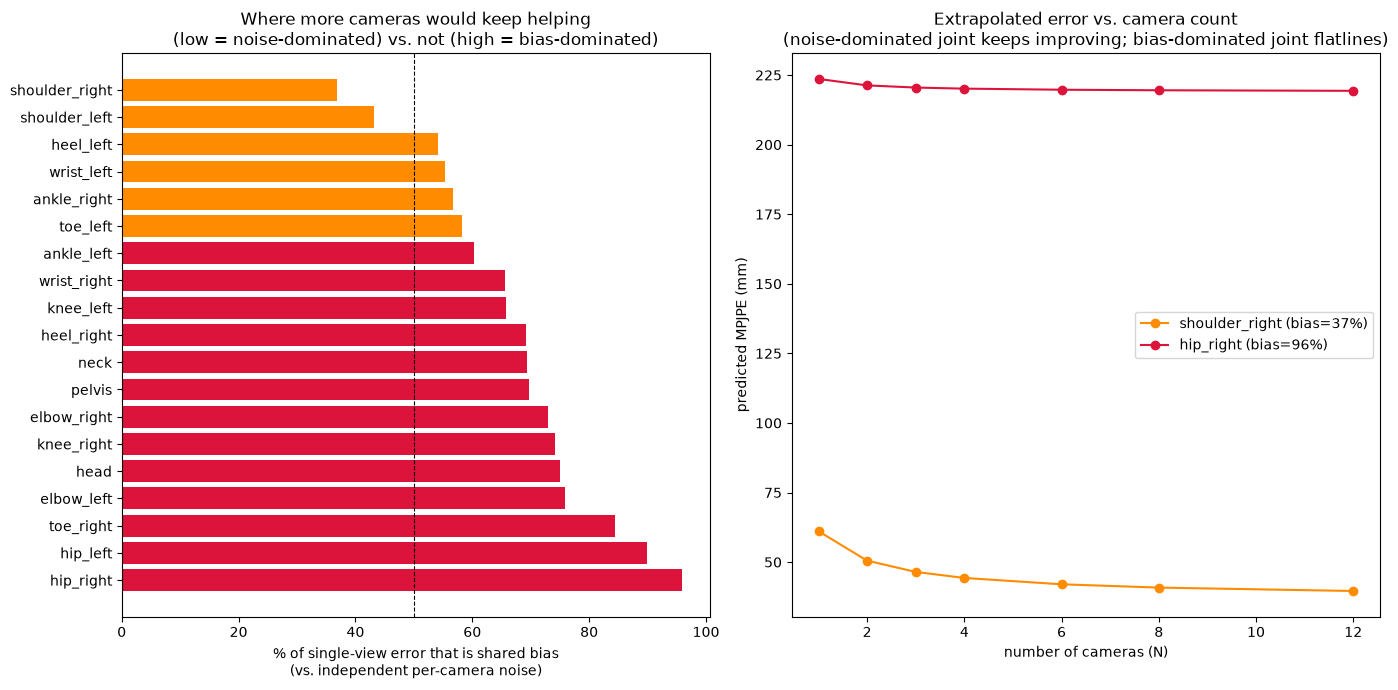

In [10]:
model = pd.DataFrame(index=CANONICAL_JOINTS)
E1 = (v1_summary["mpjpe_mm"] + v2_summary["mpjpe_mm"]) / 2
E2 = fused_summary["mpjpe_mm"]
model["E1"] = E1
model["E2"] = E2
model["bias"] = np.sqrt(np.maximum(2 * E2**2 - E1**2, 0))
model["noise"] = np.sqrt(np.maximum(2 * (E1**2 - E2**2), 0))
model["bias_fraction"] = (model["bias"]**2 / E1**2)
model["E3_predicted"] = np.sqrt(model["bias"]**2 + model["noise"]**2 / 3)
model["E4_predicted"] = np.sqrt(model["bias"]**2 + model["noise"]**2 / 4)
model["floor_as_N_to_inf"] = model["bias"]
model = model.sort_values("bias_fraction")

display(model[["E1", "E2", "E3_predicted", "E4_predicted", "floor_as_N_to_inf", "bias_fraction"]].round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
y = np.arange(len(model))
ax1.barh(y, model["bias_fraction"] * 100, color=["darkorange" if b < 0.6 else "crimson" for b in model["bias_fraction"]])
ax1.set_yticks(y)
ax1.set_yticklabels(model.index)
ax1.invert_yaxis()
ax1.set_xlabel("% of single-view error that is shared bias\n(vs. independent per-camera noise)")
ax1.set_title("Where more cameras would keep helping\n(low = noise-dominated) vs. not (high = bias-dominated)")
ax1.axvline(50, color="black", linestyle="--", linewidth=0.8)

for j, color in [("shoulder_right", "darkorange"), ("hip_right", "crimson")]:
    Ns = np.array([1, 2, 3, 4, 6, 8, 12])
    Es = np.sqrt(model.loc[j, "bias"]**2 + model.loc[j, "noise"]**2 / Ns)
    ax2.plot(Ns, Es, "o-", color=color, label=f"{j} (bias={model.loc[j,'bias_fraction']*100:.0f}%)")
ax2.set_xlabel("number of cameras (N)")
ax2.set_ylabel("predicted MPJPE (mm)")
ax2.set_title("Extrapolated error vs. camera count\n(noise-dominated joint keeps improving; bias-dominated joint flatlines)")
ax2.legend()
plt.tight_layout()
plt.show()


### The honest answer: it depends entirely on which joint

There is no single yes/no answer — the fitted model splits the 19 joints cleanly into two groups:

- **Noise-dominated joints** (`shoulder_right` 37% bias, `shoulder_left` 43%, `heel_left` 54%, `wrist_left` 55%, `ankle_right` 57%, `toe_left` 58%, `ankle_left` 60%): more than half of their single-view error is independent per-camera noise. For these, a 3rd and 4th camera would plausibly keep helping — `shoulder_right`'s predicted error keeps falling from 61mm (1 camera) to 50mm (2, matches what we actually measured) to 46mm (3, predicted) to 44mm (4, predicted), continuing to approach its ~37mm noise floor with the classic diminishing-but-real $1/\sqrt{N}$ returns.
- **Bias-dominated joints** (`hip_right` 96% bias, `hip_left` 90%, `toe_right` 84%): the model predicts a 3rd or 4th camera would do almost nothing — `hip_right` is predicted to go from 224mm (1 camera) to 221mm (2, measured) to 220.5mm (3) to 220.1mm (4), asymptoting to a 219mm floor no amount of *additional, similarly-uncalibrated* cameras escapes. That floor is the occlusion bias itself — fixable by removing the handrail or repositioning a camera to see that hip, not by adding a fifth one at another similarly-obstructed angle.

**So: would more cameras help overall?** Yes, for roughly half the skeleton (mostly distal limb joints), with real but shrinking returns per additional view. No, for the hip joints and `toe_right` specifically — those need the occlusion source addressed, not more viewpoints of the same occlusion. A real 3rd/4th camera deployment would very plausibly land close to this split, *if* the new cameras are still uncalibrated and positioned similarly casually — the one caveat worth stating plainly: this model extrapolates from exactly two data points per joint ($N{=}1,2$) and assumes future cameras behave like these two (independent noise magnitude unchanged, same shared bias). It's the best honest estimate available without actually recording a third view, not a guarantee.


In [11]:
# Cross-check: does inter-view disagreement (Phase 5, zero mocap involved)
# independently agree with which joints the bias/noise model just called
# "bias-dominated"? It should: a shared bias means both cameras agree with
# each other while both being wrong (low disagreement), while independent
# noise means the two cameras genuinely see it differently (higher disagreement).
mean_disagreement = disagreement_df.groupby("joint")["disagreement"].mean().drop("pelvis")  # pelvis is the GPA root, disagreement=0 by construction
check = pd.DataFrame({"bias_fraction": model["bias_fraction"], "disagreement": mean_disagreement}).dropna()
r_check, p_check = stats.pearsonr(check["bias_fraction"], check["disagreement"])
print(f"bias_fraction vs. inter-view disagreement: r={r_check:+.2f} (p={p_check:.2f}) -- "
      f"negative, as expected: more bias-dominated joints show less inter-view disagreement")


bias_fraction vs. inter-view disagreement: r=-0.42 (p=0.08) -- negative, as expected: more bias-dominated joints show less inter-view disagreement


## 9. Summary

- **Best-modeled joints**: `neck`, `shoulder_right`, `shoulder_left` — large, central, rarely-occluded, and mostly limited by whole-trial drift rather than genuine model error.
- **Worst-modeled joint by far**: `hip_right` — its error is almost entirely a *shared, systematic bias* (not drift, not independent noise, not even fully explained by kinematic distance from the root), consistent with the documented handrail-occlusion finding. `hip_left` and `toe_right` share the same signature to a lesser degree.
- **Everything else** falls on a real, measurable spectrum from "mostly independent per-camera noise" (shoulders, most distal limb joints) to "increasingly shared bias" (knees, elbows, head, working toward the hips) — confirmed three independent ways in this notebook: the drift-vs-shape PA-MPJPE gap, the distance-from-root correlation, and the inter-view disagreement cross-check all point the same direction.
- **Fusion is real but narrow**: it helps position accuracy for the independent-noise joints (up to ~17%), does essentially nothing for joint angles or for bias-dominated joints, and the benefit specifically comes from averaging out per-camera noise, not from the model understanding pose any better.
- **More cameras**: would plausibly keep helping roughly half the skeleton (the noise-dominated joints), with real but shrinking $1/\sqrt{N}$ returns — and would do almost nothing for `hip_right`, `hip_left`, or `toe_right` unless the actual occlusion source is addressed, no matter how many additional (similarly uncalibrated, similarly positioned) cameras are added.
